🌟 Good Morning, Everyone! 🌟

  I hope you're doing great!

🎯 Today’s Topic: Flight Price Prediction Project ✈️📊

💡 We’ll explore this exciting topic using various models, and I promise it’ll be a fun and interactive session.

⏰ We’ll kick things off in just a few minutes. Meanwhile, let’s get ready to dive in!

👉 Please stay active in the chat box 💬 for a truly amazing and engaging session.

🚀 Let’s make this a fantastic learning experience together! 🙌

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Flight_Booking (1).csv")
df

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955
...,...,...,...,...,...,...,...,...,...,...,...,...
300148,300148,Vistara,UK-822,Chennai,Morning,one,Evening,Hyderabad,Business,10.08,49,69265
300149,300149,Vistara,UK-826,Chennai,Afternoon,one,Night,Hyderabad,Business,10.42,49,77105
300150,300150,Vistara,UK-832,Chennai,Early_Morning,one,Night,Hyderabad,Business,13.83,49,79099
300151,300151,Vistara,UK-828,Chennai,Early_Morning,one,Evening,Hyderabad,Business,10.00,49,81585


In [ ]:
#eda
#null
#duplicate
#outliers

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [ ]:
df["hours"]= df["duration"].astype(int)
df["minutes"] = ((df["duration"] -df["hours"]) * 60).astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
 12  hours             300153 non-null  int64  
 13  minutes           300153 non-null  int64  
dtypes: float64(1), int64(5), object(8)
memory usage: 32.1+ MB


In [ ]:
df = df.drop(columns = ["Unnamed: 0"])

In [ ]:
df.isnull().sum()

,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0
days_left,0


In [ ]:
df.duplicated().sum()

0

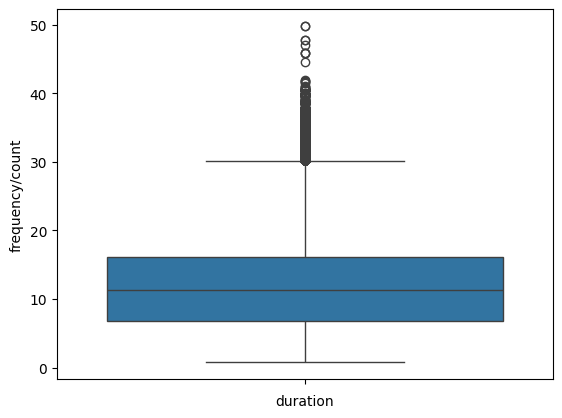

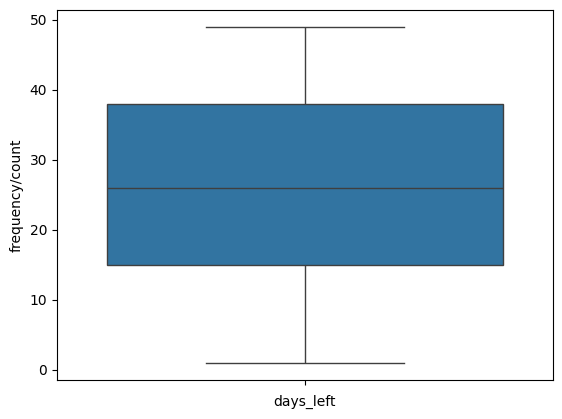

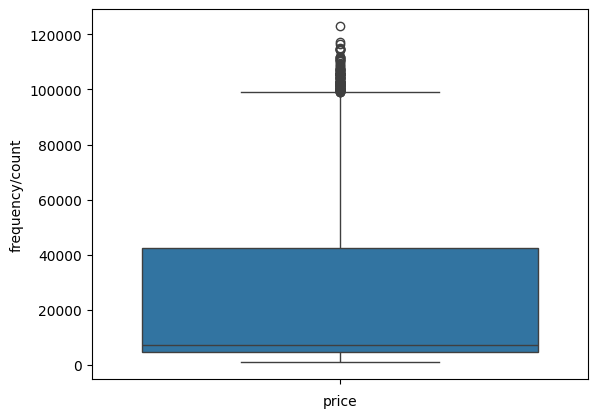

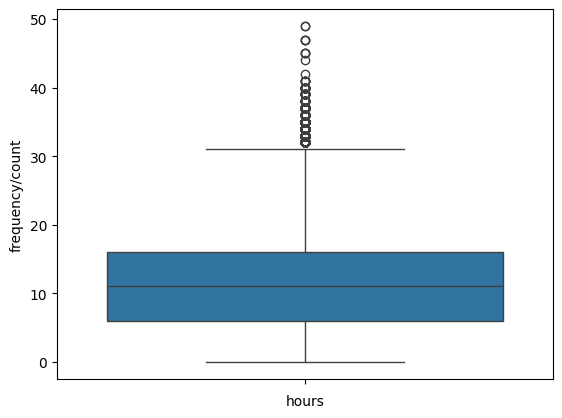

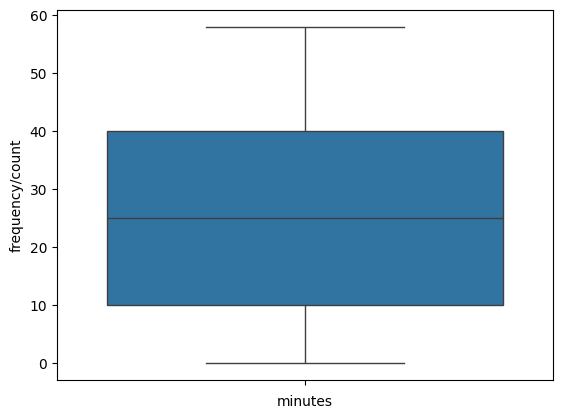

In [ ]:
#outliers
for i in df.columns:
  if df[i].dtype == "int64" or df[i].dtype =='float64':
    sns.boxplot(df[i])
    plt.xlabel(i)
    plt.ylabel("frequency/count")
    plt.show()

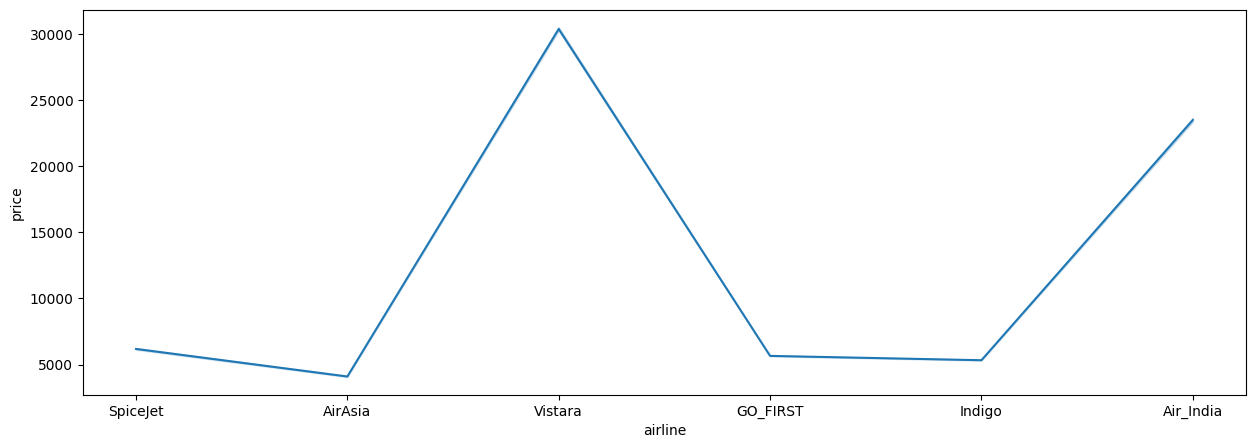

In [ ]:
#data visulation
#airlines vs price
plt.figure(figsize=(15,5))
sns.lineplot(data = df,x ='airline',y='price')
plt.show()

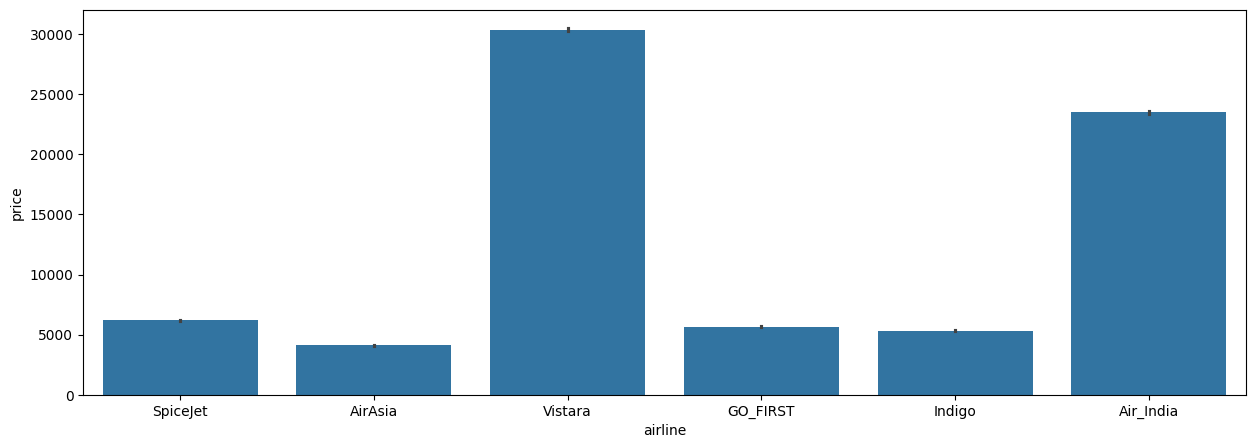

In [ ]:
plt.figure(figsize=(15,5))
sns.barplot(x='airline', y='price',data =df)
plt.show()

In [ ]:
df.corr()

ValueError: could not convert string to float: 'SpiceJet'

In [ ]:
#label encoding
from sklearn.preprocessing import LabelEncoder

In [ ]:
le = LabelEncoder()

In [ ]:
for i in df.columns:
  if df[i].dtype == 'object':
    df[i]= le.fit_transform(df[i])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  int64  
 1   flight            300153 non-null  int64  
 2   source_city       300153 non-null  int64  
 3   departure_time    300153 non-null  int64  
 4   stops             300153 non-null  int64  
 5   arrival_time      300153 non-null  int64  
 6   destination_city  300153 non-null  int64  
 7   class             300153 non-null  int64  
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
 11  hours             300153 non-null  int64  
 12  minutes           300153 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 29.8 MB


In [ ]:
df = df.drop(columns =["duration"])

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
col_list = []

for col in df.columns:
  if((df[col].dtype != 'object') & (col != 'price')):
    col_list.append(col)
X = df[col_list]
vif_data = pd.DataFrame()

vif_data["feature"] =X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i ) for i in range(len(X.columns))]

print(vif_data)

             feature        VIF
0            airline   6.701874
1             flight  12.767778
2        source_city   2.995032
3     departure_time   2.812034
4              stops   1.444730
5       arrival_time   3.816673
6   destination_city   2.948443
7              class   2.909610
8          days_left   4.121353
9              hours   4.555054
10           minutes   3.009385


In [ ]:
#MODELS

X = df.drop(columns=["price", "flight"])

y = df["price"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test,y_train,y_test = train_test_split(X, y,test_size =0.2,random_state =42)

In [ ]:
from sklearn.preprocessing import StandardScaler  #mean-0,std-1
sc = StandardScaler()

In [ ]:
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
lr = LinearRegression()

In [ ]:
lr.fit(X_train, y_train)
y_pred =lr.predict(X_test)

In [ ]:
y_pred

array([ 4490.95649163, 52714.30256602,  7855.12679107, ...,
        5814.96693875, -1359.68715502, 58762.43593672])

In [ ]:
from sklearn.metrics import *

r2 = r2_score(y_test,y_pred)
mae =mean_absolute_error(y_test,y_pred)
mape =mean_absolute_percentage_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(r2)
print(mae)
print(mape)
print(mse)
print(rmse)


0.9045755374024218
4624.144472321057
0.43506600151927816
49189618.93388746
7013.5311315975105


In [ ]:
#model ---2

from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor()

dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

y_pred

array([ 7366., 64831.,  6195., ...,  6314.,  5082., 50449.])

In [ ]:
from sklearn.metrics import *

r2 = r2_score(y_test,y_pred)
mae =mean_absolute_error(y_test,y_pred)
mape =mean_absolute_percentage_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(r2)
print(mae)
print(mape)
print(mse)
print(rmse)


0.9765019065501436
1140.413869500758
0.07282668156038458
12112850.63606581
3480.352085072114


In [ ]:
#model -3
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor()

rfr.fit(X_train, y_train)
y_pred = rfr.predict(X_test)

y_pred

In [ ]:
from sklearn.metrics import *

r2 = r2_score(y_test,y_pred)
mae =mean_absolute_error(y_test,y_pred)
mape =mean_absolute_percentage_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)

print(r2)
print(mae)
print(mape)
print(mse)
print(rmse)


0.9854983397922057
1066.415091854592
0.06946225214768598
7475348.774437038
2734.108405758089


<ipython-input-47-dee25265ce54>:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_test , label ="ACtual")
<ipython-input-47-dee25265ce54>:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_pred, label ="predicted")


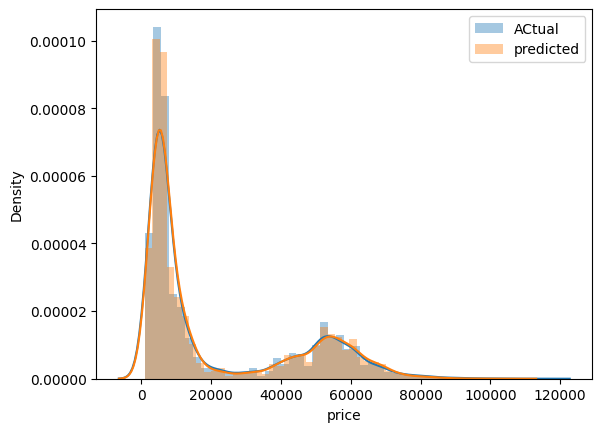

In [ ]:
sns.distplot(y_test , label ="ACtual")
sns.distplot(y_pred, label ="predicted")

plt.legend()